Nombre: _______________________Javier Peralta________________________________  Grupo BDIA. Fecha 25/05/2026

El dataset Breast Cancer Wisconsin ofrece información sobre diagnóstico de cancer M = Maligno y B=Benigno.

1. (1P) Transforma la variable categórica 'diagnosis' de acuerdo a la siguiente convención:
   
    B -> 0 y M -> 1. Muestra:
   
   a. La cabecera del dataset
   
   b. Los valores únicos transformados de la variable 'diagnósis'
   
   c. Número de cada categoría numérica.
   
   d. Muestra, mediante un histograma, la distribución de la variable categórica

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0             

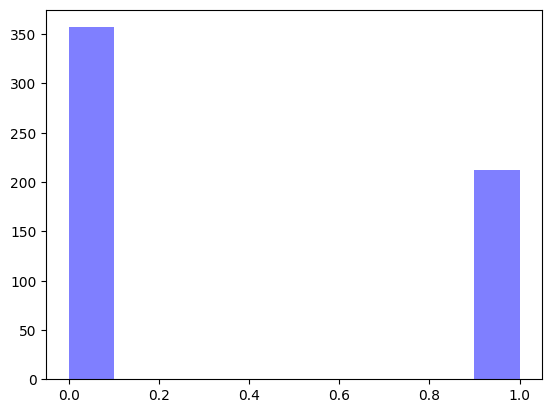

In [26]:
# Escribe aquí tu respuesta a la pregunta 1
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv('data_final.csv', delimiter = ',')

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

y = y.map({
    'B': 0,
    'M': 1
})


print(df.head())
print(y.unique())
print(y.value_counts())
plt.hist(
    y,                             
    alpha=0.5,                     
    color='b',                     
    label='B 0, M 1'  
)
plt.show()

2. (1P) Transforma las variables del dataset en tensores de PyTorch.
   
   Recuerda que para nuestro modelo (salida 1 neurona) y debe tener forma (n, 1)

In [19]:
# Escribe aquí tu respuesta a la pregunta 2
X_np = X.to_numpy()
y_np = y.to_numpy()

X_tensor = torch.tensor(X_np, dtype=torch.float32)
y_tensor = torch.tensor(y_np, dtype=torch.float32)

y_tensor = y_tensor.view(-1, 1)
print(y_tensor.shape)

torch.Size([569, 1])


3. (1P) Obtener los conjuntos de entrenamiento (75%) y test (% resto dataset).
   
   Estratifica por la variable y (ahora tensor). Incluye barajado.

In [21]:
# Escribe aquí tu respuesta a la pregunta 3
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,                
    y_tensor,               
    test_size=0.25,    
    random_state=42, 
    shuffle=True,      
    stratify=y_tensor  
)

4. (1P) Realiza el estandarizado de los conjuntos de entrenamiento y test, utilizando el objeto StandardScaler.
   
   Recuerda que al estandarizar obtenemos arrays de numpy, debes convertir arrays de numpy a tensor.
   
   Muestra el tipo final de los conjuntos de entrenamiento y test.

In [25]:
# Escribe aquí tu respuesta a la pregunta 4
scaler_std = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)
X_test_scaled = scaler_std.transform(X_test)
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test  = torch.tensor(X_test_scaled, dtype=torch.float32)
print(type(X_train))
print(type(X_test))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


5. (2P) Crear un modelo de red neuronal para clasificación binaria, utilizando el esquema de la siguiente figura:

   a. Las funciones de activación son ReLU, para las capas ocultas y sigmoide para el perceptrón de salida.
   
   b. Define la función de pérdida y el optimizador. Utiliza una tasa de aprendizaje de 0.01
   
   c. Imprime el modelo. Debe visualizarse claramente su estructura.

<img src="modelo_prueba_3_eva.png" width="800">

In [29]:
# Escribe aquí tu respuesta a la pregunta 5
modelo = nn.Sequential(
    nn.Linear(X.shape[1], 2, bias = True, dtype=torch.float32, device='cpu'), 
    nn.ReLU(),
    nn.Linear(2, 2, bias = True, dtype=torch.float32, device='cpu'),
    nn.ReLU(),
    nn.Linear(2, 1, bias = True, dtype=torch.float32, device='cpu'),
    nn.Sigmoid()
)

loss_fn = nn.BCELoss()
# definimos el optimizador
optimizador = optim.Adam(modelo.parameters(),
                        lr = 0.001)
print(modelo)

Sequential(
  (0): Linear(in_features=30, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=2, bias=True)
  (3): ReLU()
  (4): Linear(in_features=2, out_features=1, bias=True)
  (5): Sigmoid()
)


6. (3P) Realiza el entrenamiento del modelo anterior en PyTorch. Utiliza 20 épocas y tamaño de batch 10.
   
   Guardamos métricas de la época en listas para su posterior utilización.
   
   Mostramos métricas del modelo para el conjunto de test.

In [30]:
# Escribe aquí tu respuesta a la pregunta 6
n_epocas = 20

tamanho_batch = 10

batches_por_epoca = len(X_train) // tamanho_batch  

lista_loss_train = []
lista_acc_train = []
lista_acc_test = []

for epoca in range(n_epocas):

    modelo.train()

    loss_acumulada = 0.0
    acc_acumulada = 0.0
    
    for i in range(batches_por_epoca):
         
        inicio_batch = i * tamanho_batch
    
        fin_batch = inicio_batch + tamanho_batch
        
        X_batch = X_train[inicio_batch : fin_batch ]
    
        y_batch = y_train[inicio_batch : fin_batch]
        
        y_pred  = modelo(X_batch)
        
        loss    = loss_fn(y_pred, y_batch)
        
        optimizador.zero_grad()
        
        loss.backward()
        
        optimizador.step()
    
        acc = (y_pred.round() == y_batch).float().mean()
    
        loss_acumulada += loss.item()
        acc_acumulada += acc.item()

    loss_media = loss_acumulada / batches_por_epoca
    acc_media = acc_acumulada / batches_por_epoca
            
    modelo.eval()

    with torch.no_grad():
        y_pred_test = modelo(X_test)
        acc_test = (y_pred_test.round() == y_test).float().mean()

    lista_loss_train.append(loss_media)
    lista_acc_train.append(acc_media)
    lista_acc_test.append(acc_test.item())

    print(
        f"Época {epoca}: "
        f"loss_train={loss_media:.4f}, "
        f"acc_train={acc_media:.4f}, "
        f"acc_test={acc_test:.4f}"
    )       
    

Época 0: loss_train=0.7265, acc_train=0.3810, acc_test=0.3986
Época 1: loss_train=0.6632, acc_train=0.5929, acc_test=0.7972
Época 2: loss_train=0.5737, acc_train=0.8405, acc_test=0.8881
Época 3: loss_train=0.4855, acc_train=0.9048, acc_test=0.9091
Época 4: loss_train=0.4191, acc_train=0.9119, acc_test=0.9301
Época 5: loss_train=0.3753, acc_train=0.9214, acc_test=0.9441
Época 6: loss_train=0.3469, acc_train=0.9333, acc_test=0.9720
Época 7: loss_train=0.3276, acc_train=0.9571, acc_test=0.9720
Época 8: loss_train=0.3124, acc_train=0.9619, acc_test=0.9720
Época 9: loss_train=0.2990, acc_train=0.9690, acc_test=0.9790
Época 10: loss_train=0.2873, acc_train=0.9762, acc_test=0.9860
Época 11: loss_train=0.2769, acc_train=0.9762, acc_test=0.9860
Época 12: loss_train=0.2671, acc_train=0.9786, acc_test=0.9860
Época 13: loss_train=0.2581, acc_train=0.9810, acc_test=0.9860
Época 14: loss_train=0.2503, acc_train=0.9810, acc_test=0.9860
Época 15: loss_train=0.2427, acc_train=0.9810, acc_test=0.9860
Ép

7. (1P) Gráficas.
   
   a. Muestra la gráfica del valor de la función de pérdida en función del número de épocas.
   
   b. Muestra, en una gráfica, los valores del acurracy de los conjuntos de entrenamiento y de test
   
      en función del número de épocas.

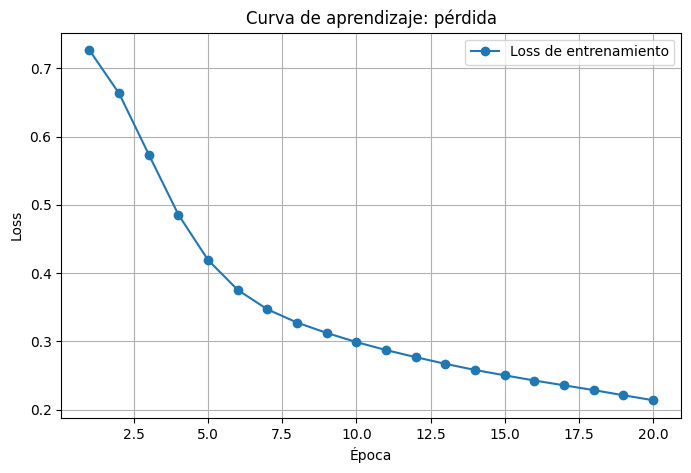

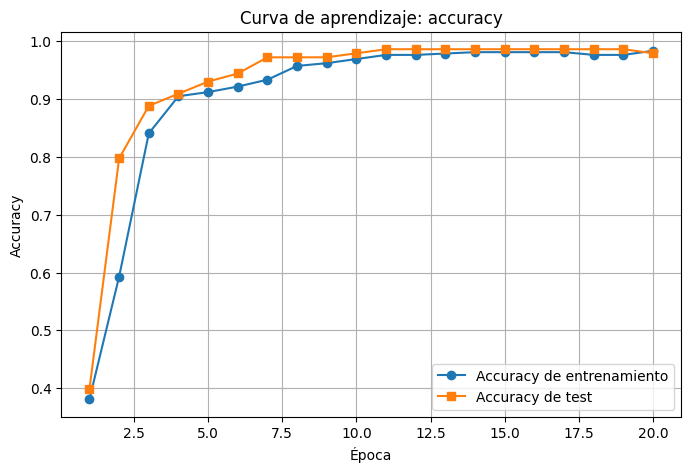

In [32]:
# Escribe aquí tu respuesta a la pregunta 7
epocas = range(1, n_epocas + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epocas, lista_loss_train, marker='o', label='Loss de entrenamiento')

ax.set_title('Curva de aprendizaje: pérdida')
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epocas, lista_acc_train, marker='o', label='Accuracy de entrenamiento')
ax.plot(epocas, lista_acc_test, marker='s', label='Accuracy de test')

ax.set_title('Curva de aprendizaje: accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

plt.show()